## Tiny Stories Dataset 

In [21]:
# Here is the code to download the TinyStories dataset and save it as plain text files. 
# You can uncomment the code below and run it in your local environment to download the dataset.




# from datasets import load_dataset
# import os

# # ── Your local folder ──────────────────────────────────────
# save_dir = "/Users/mac/Desktop/Machine Learning/DL/DB/Tinystories"
# os.makedirs(save_dir, exist_ok=True)

# print("Downloading TinyStories... (this may take a few minutes)")

# ds_train = load_dataset("roneneldan/TinyStories", split="train")
# ds_val   = load_dataset("roneneldan/TinyStories", split="validation")

# # save as plain text — stories separated by a special token
# print("Saving train.txt...")
# with open(os.path.join(save_dir, "train.txt"), "w", encoding="utf-8") as f:
#     for sample in ds_train:
#         f.write(sample["text"].strip() + "\n<|endofstory|>\n")

# print("Saving val.txt...")
# with open(os.path.join(save_dir, "val.txt"), "w", encoding="utf-8") as f:
#     for sample in ds_val:
#         f.write(sample["text"].strip() + "\n<|endofstory|>\n")

# # quick size check
# train_mb = os.path.getsize(os.path.join(save_dir, "train.txt")) / 1e6
# val_mb   = os.path.getsize(os.path.join(save_dir, "val.txt"))   / 1e6

# print(f"\nDone!")
# print(f"Train stories : {len(ds_train):,}")
# print(f"Val   stories : {len(ds_val):,}")
# print(f"train.txt     : {train_mb:.1f} MB")
# print(f"val.txt       : {val_mb:.1f} MB")
# print(f"Saved to      : {save_dir}")

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


## Dataloader

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

# Load text
data_dir = "/Users/mac/Desktop/Machine Learning/DL/DB/Tinystories"

with open(f"{data_dir}/train.txt", "r", encoding="utf-8") as f:
    train_text=f.read()
    
with open(f"{data_dir}/val.txt", "r", encoding="utf-8") as f:
    val_text=f.read()

print(f"Train characters : {len(train_text):,}")
print(f"Val   characters : {len(val_text):,}")

# Character Level tokenizer
vocab=sorted(set(train_text[:1000000]))
vocab_size=len(vocab)

stoi={ch: i for i, ch in enumerate(vocab)}
itos={i: ch for i, ch in enumerate(vocab)}


def encode(text):
    return [stoi[ch] for ch in text if ch in stoi]

def decode(ids):
    return "".join([itos[i] for i in ids])

print(f"Vocab size       : {vocab_size}")



Train characters : 1,933,888,707
Val   characters : 19,542,158
Vocab size       : 79


In [24]:
print("Itos:", itos)
print("Stoi:", stoi)

Itos: {0: '\n', 1: ' ', 2: '!', 3: '"', 4: '$', 5: "'", 6: ',', 7: '-', 8: '.', 9: '0', 10: '1', 11: '2', 12: '3', 13: '5', 14: '8', 15: ':', 16: ';', 17: '<', 18: '>', 19: '?', 20: 'A', 21: 'B', 22: 'C', 23: 'D', 24: 'E', 25: 'F', 26: 'G', 27: 'H', 28: 'I', 29: 'J', 30: 'K', 31: 'L', 32: 'M', 33: 'N', 34: 'O', 35: 'P', 36: 'Q', 37: 'R', 38: 'S', 39: 'T', 40: 'U', 41: 'V', 42: 'W', 43: 'X', 44: 'Y', 45: 'Z', 46: 'a', 47: 'b', 48: 'c', 49: 'd', 50: 'e', 51: 'f', 52: 'g', 53: 'h', 54: 'i', 55: 'j', 56: 'k', 57: 'l', 58: 'm', 59: 'n', 60: 'o', 61: 'p', 62: 'q', 63: 'r', 64: 's', 65: 't', 66: 'u', 67: 'v', 68: 'w', 69: 'x', 70: 'y', 71: 'z', 72: '|', 73: 'â', 74: 'œ', 75: '“', 76: '”', 77: '€', 78: '™'}
Stoi: {'\n': 0, ' ': 1, '!': 2, '"': 3, '$': 4, "'": 5, ',': 6, '-': 7, '.': 8, '0': 9, '1': 10, '2': 11, '3': 12, '5': 13, '8': 14, ':': 15, ';': 16, '<': 17, '>': 18, '?': 19, 'A': 20, 'B': 21, 'C': 22, 'D': 23, 'E': 24, 'F': 25, 'G': 26, 'H': 27, 'I': 28, 'J': 29, 'K': 30, 'L': 31, 'M': 

## Dataset class

In [25]:
class TinyStoriesDataset(Dataset):
    def __init__(self, text, block_size):
        self.block_size=block_size
        self.data=torch.tensor(encode(text), dtype=torch.long)
        
    def __len__(self):
        return len(self.data)-self.block_size
    
    def __getitem__(self, idx):
        x=self.data[idx:idx+self.block_size]
        y=self.data[idx+self.block_size]
        return x, y

## Build datasets & loader

In [26]:
block_size=64

train_ds=TinyStoriesDataset(train_text[:1000000], block_size)
val_ds=TinyStoriesDataset(val_text[:100000], block_size)

train_loader=DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
val_loader=DataLoader(val_ds, batch_size=128, shuffle=False, drop_last=False)

print(f"\nTrain samples    : {len(train_ds):,}")
print(f"Val   samples    : {len(val_ds):,}")
print(f"Train batches    : {len(train_loader):,}")
print(f"Val   batches    : {len(val_loader):,}")

x, y = train_ds[0]
print(f"\nSample input  : '{decode(x.tolist())}'")
print(f"Sample target : '{decode([y.item()])}'")


Train samples    : 999,936
Val   samples    : 99,936
Train batches    : 7,812
Val   batches    : 781

Sample input  : 'One day, a little girl named Lily found a needle in her room. Sh'
Sample target : 'e'


## Custom BatchNorm1d

In [27]:
class BatchNorm1d(nn.Module):
    def __init__(self, dim, momentum=0.1):
        super().__init__()
        self.momentum=momentum
        self.eps=1e-6
        
        # learnable scale (gamma) and shift (beta)
        self.scale=nn.Parameter(torch.ones(dim))
        self.shift=nn.Parameter(torch.zeros(dim))
        
        # running stats -NOT parameters , not updated by optimizer
        self.register_buffer("running_mean", torch.zeros(dim))
        self.register_buffer("running_var", torch.ones(dim))
        
    def forward(self, x):
        if self.training:
            xmean=x.mean(dim=0, keepdim=True)
            xvar=x.var(dim=0, keepdim=True)
            
            # update running stats for inference 
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
                
        else:
            # at eval time - use stable running stats , not noisy batch stats
            xmean=self.running_mean
            xvar=self.running_var
            
        x=(x-xmean)/(xvar+self.eps)**0.5
        x=self.scale*x+self.shift
        
        return x
                

## Model with BatchNorm

In [28]:
class StoryGenerator(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_hidden, n_layers=6, dropout=0.3):
        super().__init__()
        
        self.E=nn.Embedding(vocab_size, n_embd)
        
        # first layer: embedding space -> hidden space
        self.input_layer=nn.Linear(block_size*n_embd, n_hidden, bias=False)
        self.input_bn=BatchNorm1d(n_hidden)
        
        # dropout layer - randomly zeros neurons during training
        self.drop=nn.Dropout(dropout)
        
        # stack of hidden layers, each followed by BatchNorm
        # nn.ModuleList so pytorch registers all layers properly
        self.hidden_layers=nn.ModuleList([
            nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers)
        ])
        
        self.hidden_bns=nn.ModuleList([
            BatchNorm1d(n_hidden) for _ in range(n_layers)
        ])
        
        # output layer
        self.out=nn.Linear(n_hidden, vocab_size)
        
        # good initialisation - prevents dead neurans at start
        self._init_weights()
        
    def _init_weights(self):
        for layer in self.hidden_layers:
            nn.init.xavier_uniform_(layer.weight)
            
        # shrink output layer -> uniform distribution at step 0
        nn.init.normal_(self.out.weight, std=0.01)
        nn.init.zeros_(self.out.bias)
        
    def forward(self, x):
        # x: (B, block_size)- integers
        x=self.E(x)
        B, T, C=x.shape
        x=x.view(B, T*C)
        
        # input layer+ BN+activation
        x=self.input_bn(self.input_layer(x))
        x=torch.tanh(x)
        x=self.drop(x)
        
        # hidden layers-BN before activation (best practice)
        for layer, bn in zip(self.hidden_layers, self.hidden_bns):
            x=torch.tanh(bn(layer(x)))
            x=self.drop(x)
            
        return self.out(x)
    
    
    @torch.no_grad()
    def generate(self, seed_text="Once upon a time", max_new_chars=300, temperature=0.8):
        
        self.eval()
        
        # encode seed and take last block_size chars
        context = encode(seed_text)[-block_size:]
        
        # ── THIS was missing — left-pad with 0s if seed is shorter than block_size ──
        context = [0] * (block_size - len(context)) + context
        
        result = list(seed_text)

        for _ in range(max_new_chars):
            x      = torch.tensor([context], dtype=torch.long).to(device)
            logits = self(x)
            probs  = F.softmax(logits / temperature, dim=-1)
            ix     = torch.multinomial(probs, 1).item()
            result.append(itos[ix])
            context = context[1:] + [ix]   # slide window forward

        self.train()
        return "".join(result)
        

In [30]:
model=StoryGenerator(
    vocab_size=vocab_size,
    n_embd=64,
    block_size=block_size,
    n_hidden=512,
    n_layers=6,
    dropout=0.3
).to(device)

total_params=sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 3,722,767


## Training Loop with Loss Tracking

In [31]:
optimizer=torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler=torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

epochs=10

train_losses, val_losses=[], []

for epoch in range(1, epochs+1):
    # Training
    model.train()
    running_loss=0.0
    
    for x_batch, y_batch in train_loader:
        x_batch=x_batch.to(device)
        y_batch=y_batch.to(device)
        
        logits=model(x_batch)
        loss=F.cross_entropy(logits, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss+=loss.item()
        
    avg_train=running_loss/len(train_loader)
    train_losses.append(avg_train)
    
    
    # Validation
    
    model.eval()
    running_val=0.0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch=x_batch.to(device)
            y_batch=y_batch.to(device)
            logits=model(x_batch)
            running_val+=F.cross_entropy(logits, y_batch).item()
            
    avg_val=running_val/len(val_loader)
    val_losses.append(avg_val)
    
    scheduler.step()
    
    print(f"Epoch {epoch:2d}/{epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")
    
    # generate a sample every 2 epochs to watch progress
    if epoch%2==0:
        sample = model.generate("Once upon a time", max_new_chars=150)
        print(f"\n--- Sample ---\n{sample}\n")

Epoch  1/10 | Train: 2.1301 | Val: 1.6602
Epoch  2/10 | Train: 1.7416 | Val: 1.4475

--- Sample ---
Once upon a time said. I want stoing in the girl. She saund the girl and sto deach the pittle out he doand to the banny saxe his stiry for his cone to your and said, 

Epoch  3/10 | Train: 1.6037 | Val: 1.3499
Epoch  4/10 | Train: 1.4941 | Val: 1.2727

--- Sample ---
Once upon a time and Lily something for bry. He wanted to play home and said, "Selt cime of a at a mill. They felt in the feel she perbed pill and not a big created t

Epoch  5/10 | Train: 1.4462 | Val: 1.2355
Epoch  6/10 | Train: 1.4122 | Val: 1.2116

--- Sample ---
Once upon a time says, "Yow, be care playhe went dad the saw a girl, the didn't want the brank. She fer make the happy. She end something like to quickly happy in of 

Epoch  7/10 | Train: 1.3684 | Val: 1.1866
Epoch  8/10 | Train: 1.3475 | Val: 1.1739

--- Sample ---
Once upon a time the back and Timmy was so happy and reached his a mone was who bear something h

## Loss Plot & Final Generation

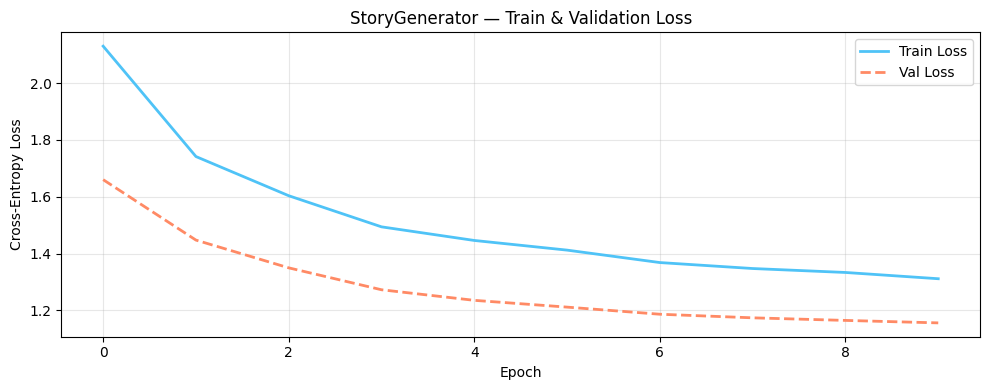


──────────────────────────────────────────────────
Once upon a time fun, a big the put a bear named Timmy. He made ot one was very happy. 

Jell was so play, the park.

It wait it was excited to explore. They saw a time amaze. He was back have who dog was so come and found it flower. She thought the peep and the little girl was a small wanted to explore you, she wa

──────────────────────────────────────────────────
The little dog car a sven the grass. He asked they were happy to said, "I want to fly and for a low the bird the parefble ran around and the tried a paint was so the is repicy the little girl started to the was bark and resting and shared in the water to play with his mom was she was very much bears.

Dadne are i

──────────────────────────────────────────────────
In a forest far away, and Ben sees a need well. 

Lily in the did not for their got it a big peanny's look she sold becaming and a found a little girl and the little brocks and happy and psother on the snepped an

In [32]:
# ── Loss curves ───────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="#4fc3f7", lw=2)
plt.plot(val_losses,   label="Val Loss",   color="#ff8a65", lw=2, linestyle="--")
plt.title("StoryGenerator — Train & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Generate final stories ────────────────────────────────
model.eval()
prompts = ["Once upon a time", "The little dog", "In a forest far away"]
for prompt in prompts:
    print(f"\n{'─'*50}")
    print(model.generate(prompt, max_new_chars=300, temperature=0.8))

## N-Gram Labguage Models (Bigram Model)

In [33]:
from collections import defaultdict, Counter
import random
import math

# Bigram Model

class BigramModel:
    def __init__(self):
        self.counts=defaultdict(Counter)
        
    def train(self, text):
        for i in range(len(text)-1):
            context=text[i]
            next_ch=text[i+1]
            self.counts[context][next_ch]+=1
        print(f"Bigram trained | unique contexts: {len(self.counts):,}")
        
    def predict_probs(self, context):
        # context is last 1 character 
        c=self.counts[context[-1]]
        total=sum(c.values())
        if total==0:
            # unseen context-uniform distribution over vocab
            return {ch:1/len(vocab) for ch in vocab}
        return {ch : cnt/total for ch, cnt in c.items()}
    
    def loss(self, text):
        total_loss=0
        n=0
        for i in range(len(text)-1):
            context=text[i]
            next_ch=text[i+1]
            probs=self.predict_probs(context)
            p=probs.get(next_ch, 1e-8)
            total_loss+=-math.log(p)
            n+=1
        return total_loss/n
    
    def generate(self, seed_text="Once", max_new_chars=300, temperature=1.0):
        result=list(seed_text)
        context=seed_text[-1]
        for _ in range(max_new_chars):
            probs=self.predict_probs(context)
            chars=list(probs.keys())
            weights=[probs[ch]**(1/temperature) for ch in chars]
            total=sum(weights)
            weights=[w/total for w in weights]
            next_ch=random.choices(chars, weights=weights)[0]
            result.append(next_ch)
            context=next_ch
        return "".join(result)
    

## N-Gram Model

In [34]:
class NGramModel:
    def __init__(self, n):
        self.n=n
        self.counts=defaultdict(Counter)
        
    def train(self, text):
        for i in range(len(text)-self.n):
            context=text[i:i+self.n-1]
            next_ch=text[i+self.n-1]
            self.counts[context][next_ch]+=1
        print(f"{self.n}-gram trained | unique contexts: {len(self.counts):,}")
        
    def predict_probs(self, context):
        #take last N-1 chars of whatever context is passed
        ctx=context[-(self.n-1):]
        c=self.counts[ctx]
        total=sum(c.values())
        if total==0:
            return {ch:1/len(vocab) for ch in vocab}
        return {ch: cnt/total for ch, cnt in c.items()}
    
    def loss(self, text):
        total_loss=0
        n=0
        for i in range(len(text)-self.n):
            context=text[i: i+self.n-1]
            next_ch=text[i+self.n-1]
            probs=self.predict_probs(context)
            p=probs.get(next_ch, 1e-8)
            total_loss+=-math.log(p)
            n+=1
            
        return total_loss/n
    
    def generate(self, seed_text="once upon a time", max_new_chars=300, temperature=1.0):
        result=list(seed_text)
        context=seed_text[-(self.n-1):] # last n-1 chars
        for _ in range(max_new_chars):
            probs=self.predict_probs(context)
            chars=list(probs.keys())
            weights=[probs[ch]**(1/temperature) for ch in chars]
            total=sum(weights)
            weights=[w/total for w in weights]
            next_ch=random.choices(chars, weights=weights)[0]
            result.append(next_ch)
            context=(context+next_ch)[-(self.n-1):] # slide windom
        return "".join(result)
    

In [37]:
ngram_train=train_text[:1000000]
ngram_val=val_text[:100000]

bigram=BigramModel()
trigram=NGramModel(n=3)
fourgram=NGramModel(n=4)


# Train

bigram.train(ngram_train)
trigram.train(ngram_train)
fourgram.train(ngram_train)


# Compare losses

print("\n── Validation Loss Comparison ──")
print(f"Bigram   : {bigram.loss(ngram_val):.4f}")
print(f"Trigram  : {trigram.loss(ngram_val):.4f}")
print(f"4-gram   : {fourgram.loss(ngram_val):.4f}")
print(f"MLP      : ~1.17  (from your graph)")

# Generate from each model
seed = "Once upon a time"
print(f"\n── Bigram ──\n{bigram.generate(seed, 300)}")
print(f"\n── Trigram ──\n{trigram.generate(seed, 300)}")
print(f"\n── 4-gram ──\n{fourgram.generate(seed, 300)}")
print(f"\n-- Neural Network--\n:{model.generate(seed, max_new_chars=300, temperature=1.0)}")

Bigram trained | unique contexts: 79
3-gram trained | unique contexts: 1,035
4-gram trained | unique contexts: 6,615

── Validation Loss Comparison ──
Bigram   : 2.2968
Trigram  : 1.6758
4-gram   : 1.3325
MLP      : ~1.17  (from your graph)

── Bigram ──
Once upon a time prancair. cor theend w ncomed wilpryondalfrinamoutothofun. an a al id fe, hetr oke a hewasppoos t fo t Nopan bin co yod ghoks ds ftid, tht y atof aist s w Em Hen, tisapir shanellolede wamiferk. fo acig s avewa.

Head Shn l wa tand tootouil. lom lar m abe ak towothelicime. d hthed. wind.

Lithe whit

── Trigram ──
Once upon a timed look you coze, are sommy.

Thad hed spettle fries his birs days. Don yould com Furne wery a prow arow a creep ticall an the says, not mad. Do scollook comee. The fanto nod ah the ands.

Samartim toy a righ ting wagaingere spas wass notily. She trow they pone ger, "Loodde was gir brieng shis ver. "

── 4-gram ──
Once upon a time felt veil you new it's and came thened.

"I done dolled spect the